# GIT Tutorial

#### Jorge A. Gómez García - jorge.gomez.garcia@cajal.csic.es

# Initial configurations

Before running this tutorial, make sure that you have created a new environment called `tutorial`. This environment will serve as a kernel for the current notebook.

Use the following command in a terminal:

`>> conda create -n tutorial python=3.8 ipykernel ipywidgets`

Then, activate the environment that just created on the terminal using the following:

`>> conda activate tutorial`

Install the package that is used for showing diagrams 

`>> pip install nb-js-diagrammers`

Now, you can open VSCode to use the kernel that you just configured. 

Make sure to choose the correct kernel (`tutorial`) on VSCode on the top right corner.

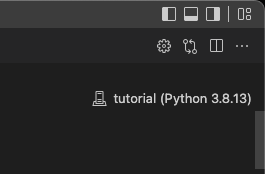

In [ ]:
# Remove files for reproducibility
! rm -rf .git
! rm -rf TEMP
! rm hola_mundo.txt hola_mundo2.txt hola_mundo3.txt new_hola_mundo.txt .gitignore

In [1]:
# Extension to show diagrams
%load_ext nb_js_diagrammers

# What is this tutorial about?

- What is GIT and how to use it
- Introduction to the group repository
- Book of style for writing code in the group of repository
- Indirectly presenting:
    - Python (conda, pip)
    - Jupyter notebooks
    - Markdown
    - VSCode

# What is GIT?

- Open Source project
- Version control system
    - More precisely a distributed control system
- Serves to track changes in code
- Helps programmers to work collaboratively

# What can GIT do?

An example of a common use case is presented next.
If a repository keeps being updated, and you need to keep track of these changes, constantly renaming might be a cumbersome option

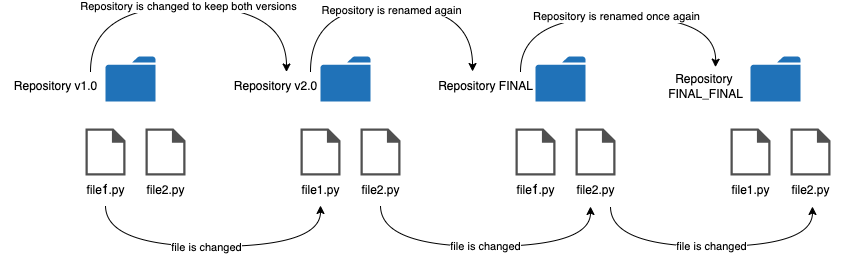

If two users perform changes on the same repository, and they end up working in the same files, it might result in data loss as some users might overwrite others work

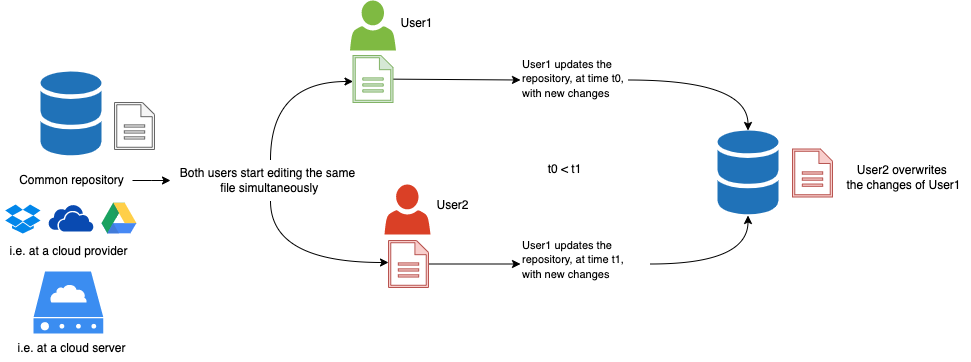

If someone introduces a change that breaks the code, it might be helpful to return to a previous state on which the code was working properly.

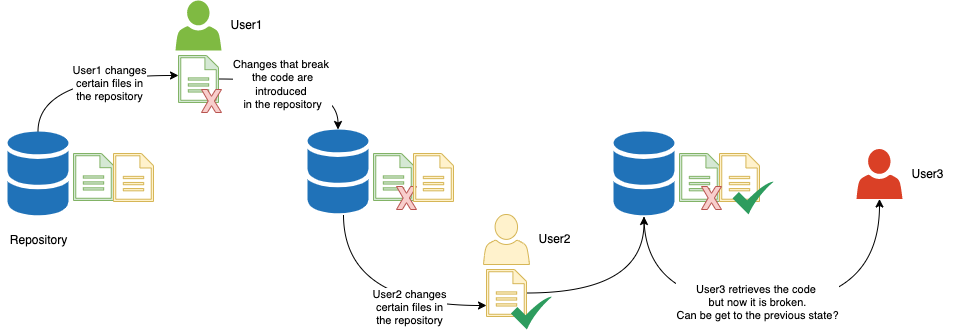

GIT can:
- Simplify the workflow of a team when working with code
- Keep track of changes in code
- Allow to control and deal with changes made simultaneously by several team members 
- Allow to return to a previous state, in case disruptive changes are made to the code 

# Popular remote GIT hostings

They serve to host repositories. 
They also allow the construction of pipelines for continous integration/continous delivery.

- **Github** (https://github.com/)
    - The most popular remote GIT service. 
    - By Microsoft
- **Gitlab** (https://about.gitlab.com/) 
    - Github competitor. 
    - Open source. 
    - Can be deployed in a personal server.
- **Bitbucket** (https://bitbucket.org/)
    - By Attlasian. 
    - Good integration with the Atlassian stack (Confluence, JIRA)

# GIT general commands

Check if GIT is installed by opening a terminal (or by running the next cell in a Jupyter notebook). 

> **Note:**
>
> You can run a cell by pressing the play button located to the left of the cell, or you can use the shortcut `shift`+`intro` to run current cell and move to the next. `ctrl`+`intro` if you want to run and stay in the current cell.

In [2]:
! git version

>**Note:** 
>
> the `!` symbol before the command allows the cell to be run as it were a shell terminal

The GIT package has a set of functions that can be used to perform actions on the working directory. To retrieve a list of the available actions use the help command

In [4]:
! git help

## Edit configuration file

Before using GIT, some fields have to be filled in the configuration file.
This configuration file holds information about the user that is currently making changes, including name, email, etc.

To check the contents of the configuration file, use the command in the next cell for reading the file in an *editor*

In [2]:
! git config --global -l

> **Note:** 
>
> You can also use `git config --global -e` for edition (outside the jupyter environment)

You can also make changes using the terminal. For instance, to change `name` to "usuario" in the config files, use:

In [7]:
! git config --global user.name "jorge a."

You can also change the `email` field to "usuario@direccion.es" in the config files using:

In [9]:
! git config --global user.email "jorge.gomez.garcia@cajal.csic.es"

Now list the new config file parameters, to check that the changes have been made:

In [10]:
! git config --global -l

## Git repository structure

Git works by creating a repository (often named `main` and previously called `master`) that holds all the changes made to the code. The process has several elements including:
- **Working directory or working tree:** where the local version of the code resides. This is equivalent to a local folder with all the files to be version controlled. This is the area where the code is often modified before being sent to the staging area or to the local/remote repository.

- **Staging area or index:** once changes are made to the code (creation, modification, deletion of files). The changes have to be temporarly indexed into the staging area. Those changes are not version controlled yet, but a first reference to these changes is made.

- **Local repository:** contrary to the working directory, this works a local database that stores all the changes that have been made. This is where the version controlled code resides **locally**. The Local Repository is the .git directory, with reference to *commits*.
A commit captures a snapshot of the code, which is a controlled version of the code. 

- **Remote repository:** since the objective of the version control is to allow several people to work in the same codebase, a distributed system is often used, a.k.a, the remote repository. The remote repository is often a computer server that runs a git server, or a githosting service such as github or gitlab and to which a team can access to work in parallel.

- **Stash:** the stash is the place where temporary changes are saved. This is often used to store changes, to work in something else, before returning to work again in the code.

> **NOTE:**
> 
> `HEAD` is a pointer that referred to the commit on which the repository is positioned. It is often set to the latest commit/snapshot, although it can be changed to return to a previous snapshot in the version history
>
> By default once you create a repository, a branch (more on that later) called `main` is created, and which contains reference to the most stable version of the codebase

A relationship of all the elements in the git repository are shown next:

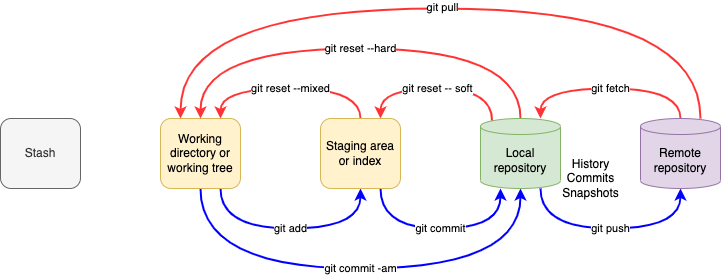

# Repository initialization: Create working directory or tree

> **NOTE:**
>
> Please ignore code below. Only for the visualization of the flowcharts

In [11]:
%%mermaid_magic -h 70

graph LR
    A[Working directory/tree]:::current_node --> B[Staging area]
    B --> C[Local Repository]
    C --> D[Remote Repository]

    classDef current_node fill:red,stroke:#333,stroke-width:4px


The working directory is the local folder where the code resides. You can instantiate any folder to be version controlled by creating a GIT repository.

To initializes a repository, the `git init` command is used.

In [12]:
! git init

This create the **local repository**. 

> **Note:**
> 
> This local repository is empty since you have to include programmatically each one of the files you want under version control.

Now, let's check the status of the local repository

In [13]:
! git status

This status can also be shown in silent mode (print is presented in a more compact version)

In [14]:
! git status -s

You can now observe that none of the files in the repository are version controlled. They are untracked (`??` symbol)

# Staging area

In [15]:
%%mermaid_magic -h 100

graph LR
    A[Working directory/tree] --stage/add--> B[Staging area]
    B:::current_node --unstage --> A
    B --> C[Local Repository]
    C --> D[Remote Repository]

    classDef current_node fill:red,stroke:#333,stroke-width:4px

## Stage files

Staging adds files to the index or staging area. This is the first step before the construction of the local repository

Fist, let's create some files to do some testing

In [16]:
! echo "Hola Mundo!" > hola_mundo.txt
! echo "Hola Mundo!" > hola_mundo2.txt
! echo "Hola Mundo!" > hola_mundo3.txt

Lets see the status of the repository

In [17]:
! git status -s

As you can see by the `??` symbol, no file has been added yet to the repository. These files are `untracked`. 

There are several manners to add files to the index.

Lets add one of files to the staging area, using explicitily the name of the file

In [18]:
! git add hola_mundo.txt

The file `hola_mundo.txt` has been staged

In [19]:
! git status -s -b

Note the `A` symbol that tell us that the file has been indexed, staged or added

Files can also be staged using the extension (`.txt`)

In [20]:
! git add *.txt 

The files `hola_mundo2.txt` and `hola_mundo3.txt` are now_ staged

In [21]:
! git status -s -b

All files can be staged as well by using the `--all` parameter

In [22]:
! git add --all

The files `GIT_tutorial.ipynb` and the content of the folder `Imgs` have been staged

In [23]:
! git status -s -b

Similarly, `! git add .` can be used, but this only stages new and modified files, but not the deleted ones

Likewise, `! git add -u` stages modified and deleted files, but no new files

## Unstage files

To unstages files, use the command `git reset --mixed` 

In [24]:
! git reset -- hola_mundo.txt --mixed

In [25]:
! git status -s -b

`hola_mundo.txt` is now unstaged (`??` symbol)

To unstage all files use the following:

In [26]:
! git reset -- .

In [27]:
! git status -s -b

## GIT Reset

**`GIT reset`** is a special command, as it allows you to return your code from the latest snapshot to the `working tree`, `to the staging area`, to another snapshot (commit), or simply to remove all the changes made in the working directory (return to a previous commit). 

The reset mode depend on the flag that is used as input:
- In *mixed mode*, the repository is reseted and set to a previous snapshot. The staging are will be reseted (changes are discarded), but the working tree will remain the same, i.e., all the staged files will be unstaged, but none of the changes in the working directory will be reseted.
- In *soft mode*, the repository is reseted and set to a previous snapshot. The staging area will be left unchanged, as well as the working tree.
- In *hard mode*, all changes are lost. *Use with Caution!*

To summarize the modes of operation, consider the following table:
| Mode  | Repository | Staging area | Working tree |
|-------|------------|--------------|--------------|
| soft  | reset | left unchanged | left unchanged    |
| mixed | reset | reset   | left unchanged    |
| hard  | reset | reset   | reset      |

In [28]:
%%mermaid_magic -h 530

sequenceDiagram
    Note right of Repository: commit
    Note right of Staging area: add
    Note right of Working tree: Code changes
    Repository ->> Staging area: git reset --soft
    Repository ->> Working tree: git reset --mixed
    Repository ->> Previous commit: git reset --hard

    Note right of Previous commit: The line shows the code changes<br/> that are reseted (destroyed)


Before moving to the next section, lets stage all files again

In [29]:
! git add .

In [30]:
! git status -s -b

# Local repository

In [31]:
%%mermaid_magic -h 100

graph LR
    A[Working directory/tree] --> B[Staging area]
    B --commit--> C
    C:::current_node --git reset --soft --> B
    C[Local Repository] --> D[Remote Repository]

    classDef current_node fill:red,stroke:#333,stroke-width:4px

First, we can list all the commits that are made in the local repository, i.e., check the `snapshots` that are saved in the GIT folder 

In [32]:
! git log


As no commits exist in the repository, this is indicated in the cell output above.

> **Note:**
>
> `git status` serves to check the working tree and the staging area. `git log` serves to check the committed snapshots.

## Commit files

To commit, a `MESSAGE` has to be included to the already indexed/staged files. This creates a snapshot/commit in the local repository history

In [33]:
! git commit -m "First commit"

The new commit can now be seen in the history

In [34]:
! git log

Messages can also be ammended, serving to correct the message that has been commited before

In [35]:
! git commit --amend -m "Ammended first commit"

To shows changes in branches use again:

In [36]:
! git log

This information can be added in a shorter manner, by using the following command. This is usefull when many commits have been made to the code.

In [37]:
! git log --oneline --decorate --all --graph

In [38]:
! git status

## Uncommit

To remove the previous commit you can use `git reset` or `git revert`. Each one of these instructions has their own pecularities. But now, and for the sake of simplicity we will stick to `git reset`.

Lets create a new file called `new_hola_mundo.txt` and modify the file `hola_mundo.txt` 

In [39]:
! echo "New Hola Mundo!" > new_hola_mundo.txt
! echo "New Hola Mundo!" > hola_mundo.txt

The new and the modified files are not staged or commited

In [40]:
! git status -s -b

>**Note:**
>
> The `M` symbol next to `hola_mundo.txt` indicates that the file has been modified

Now, lets perform stage and commit operations jointly

In [41]:
! git add . && git commit -m"new hola mundo added"

> **Note:**
>
> You can also use `git commit -am "MESSAGE"` to stage and commit at the same time

Lets check all the commits that have been made

In [42]:
! git log --oneline --decorate --all --graph

To remove this commit, use the command `! git reset --soft HEAD~1`. In this command `HEAD` is referred to the latest commit or snapshot and `~1` means pointing to the latest commit-1

In [43]:
! git reset --soft HEAD~1

In [44]:
! git log --oneline --decorate --all --graph

As a result, there is only one commit in the repository. Also, note that the previously modified files are not staged, but they remain in the `working directory`

In [45]:
! git status -s -b

Before moving, lets commit the changes

In [46]:
! git commit -am"New changes introduced"

In [47]:
! git status -b

In [48]:
! git log --oneline --decorate --all --graph

# Remote repository

The remote repository is the place where the distributed abilities of GIT shine. 

Remote repositories allow several people to access to the same codebase, constantly using pulling, pushing and fetching actions to update and modify the codebase and avoid conflicts with all the commits made by the different users working on the repository.

Remote repositories are often hosted in a GIT service such as Github, a web server, etc. but they can also be hosted in a local machine.

In [3]:
%%mermaid_magic -h 120

graph LR
    A[Working directory/tree] --> B[Staging area]
    B --> C
    C[Local Repository] --push--> D[Remote Repository]:::current_node
    D --fetch--> C
    D --pull - clone-->A

    classDef current_node fill:red,stroke:#333,stroke-width:4px

> **Note:**
>
> In GIT, the remote repository is often known as `remote`
>
> You will also find the term `origin` which is a local alias to the remote repository url. It is the predefined name that the remote repository receives.

### Clone, fetch and pull a repository

Most often, when working with a remote repository, the first stage consists on cloning the `remote repository` to the local `working tree`. To this end a url is often used (although other methods exist).

For instance, Github allows to directly copy a public repository to the working directory using a url, ssh, or Github command line options.

As an example, Pytorch, a popular python library, presents a url that looks like the following.

![](imgs/clone_github.png)

- The command you should input to clone this repository to your local computer is the following:
    - `git clone https://github.com/pytorch/pytorch.git`
- To update the local repository to the latest version in the remote repository, the command to be used should be `git pull` instead.

> **Note:** think of `clone` as downloading the repository to your machine (usually this done only once), while `pull` means updating your repository (which can be on a constant fashion)

- Finally and unlike `git pull` and `git clone` that download the remote repository to your `working directory`, `git fetch` updates the `local repository` with the changes in the `remote repository`

![](imgs/fetch_vs_pull.png)

### Push

To push code changes from the `local repository` to the `remote repository`, the command `git push` is used.

> **Note:**
>
> Once a push has been pushed to a remote repository, a review operation to accept the merged changes is required

# Branches

Branches are critical in any distributed version control system, as it allows the concurrent work of several people to access to the same codebase. Branches permit the addition of features, the creation and/or modification of files, simultaneously, avoiding overwriting issues.

Git works by default with branches.

Indeed, the main branch of a repository, which is often the version that contains the most stable developments in the code, is called the `main` branch. This is also the default branch when a repository is created.

As a matter of example, in the repository that we have created we have just the `main` branch as no other has been created:

In [4]:
! git log

In this case, the `HEAD` is in the latest commit, and points (->) to the `main` branch in the local repository

An illustration of the idea of `main` branches and derived branches is shown next:

In [2]:
%%mermaid_magic -h 280

gitGraph
       commit
       commit
       branch feature
       commit
       commit
       commit
       checkout main
       merge feature
       commit
       commit
       branch new_feature
       commit
       checkout main
       merge new_feature
       commit

In this case, the branches `feature` and `new_feature` are created to introduce new features to the code. `feature` and `new_feature` can even be controlled by different users.

`feature` and `new_feature` branches can be thought as an independent version of the `main` branch, which are used to introduce these new changes.

To update and include the new features in the codebase, a `merge` operation has to be performed to push the changes to the `main` branch. 

### Create and delete branches

To create a branch, the command `git branch NAME` is used.

Lets create a new branch named `feature1`

In [ ]:
! git branch feature1

To list all the available branchs (remote and local) use the following command:

In [ ]:
! git branch -a

In this case, two branches exist, `main` and `feature1`. The `*` indicates on which branch we are located at the moment.

This information can also be retrieved from the `git log` command, although it is not as clear as with `git branch -a`

In [ ]:
! git log --oneline --decorate --all --graph

To move to the newly created branch, and start introducing new changes, the following is used:

In [ ]:
! git checkout feature1

Now, `*` should be in the `feature1` branch, indicating that we are working an independent version of the `main` branch.

In [ ]:
! git branch -a

If we wanted to delete the branch, first we move to another branch and use the following command

In [ ]:
! git checkout main
! git branch -d feature1

The `feature1` branch has been deleted.

In [ ]:
! git branch -a

### Merge branches

`git merge BRANCH_NAME` serves to merge the branch `BRANCH_NAME` to `main` the branch.

Once again, lets create a branch. But this time, we can do the branch creation and pointing to the new branch in one single command by means of `git checkout -b BRANCH_NAME`

In [ ]:
! git checkout -b feature1

In [5]:
! git branch -a

Now, to test the merging operations, the `new_hola_mundo.txt` is modified

In [ ]:
! echo "new changes to test merging" >> new_hola_mundo.txt

In [ ]:
! cat new_hola_mundo.txt

In [ ]:
! git status -s -b

Lets commit these new changes

In [ ]:
! git commit -am"Modifications to test merging"

In [ ]:
! git status

This commit, is now ready to be `merged` to the `main` branch (the one that contains the most polished version of the code)

First, move to another branch

In [ ]:
! git checkout main

Now, merge

In [ ]:
! git merge feature1

And delete the merged branch, as it is no longer useful.

In [ ]:
! git branch -d feature1

Lets check if the changes have been introduced:

In [ ]:
! git log

In [ ]:
! git log --oneline --decorate --all --graph

In this case, the latest commit, made on the `feature1` branch, has been `merged` to the `main` branch. 

# Ignore files

Sometimes it is desirable to ignore files when version controlling software. For instance, configuration files of the IDE, or temporary files of no use to the codebase. To deal with these, a file `.gitignore` is created. This files includes information of what to ignore.

To test `.gitignore`, lets create a new folder called `TEMP` with a file inside. None of these will be of no interest to the codebase.

In [ ]:
! mkdir TEMP
! echo "thrash" >> TEMP/thrash.txt

In [ ]:
! git status -s -b

Now, create a new file called `.gitignore` and include ignore rules that will serve GIT to know what to version control and what not automatically.

In [ ]:
! echo "TEMP" >> .gitignore

If `git status` is run again, the `TEMP` folder will be ignored.

In [ ]:
! git status -s -b

# Remote repositories in the NRG

We are working on creating a common repository for the laboratory that holds code for every project on which we are involved. 
To this end, github is being used for hosting purposes.

The idea is to keep all the codes developed in the laboratory in a single place:
- For reutilization
- To make the introduction of new members of the group easier
- To make incremental codebases 
- To allow collaborative work among team members

The following image illustrates one Github `organization` for a project on which we are currently involved. 

This `organization` works as a folder containing a set of `remote repositories`

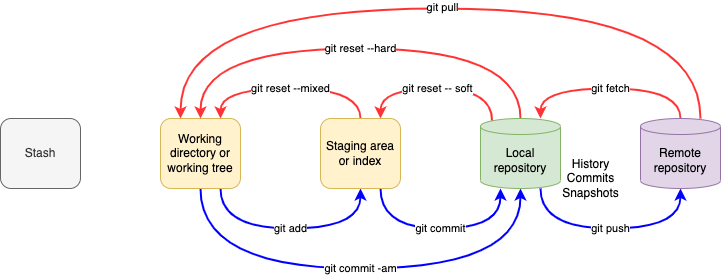

- An `organization` is composed of several `remote repositories` with different atomic operations.

- The `organization` allows to control and restrict access to just a few members that can fully modify and make changes to the code, for instance, just the members of a research project.

- The `organization` is public, but the `remote repositories` have to be set to **private**, so that no one outside of the `organization` can access the codebase. Make sure that the `remote repositories` are set to private.

> **Words of advice:**
>
> Since the organization can hold several repositories, and larges amount of code, please be cautious with the access. 
> - Ensure to use strong passwords for your Github account. Even better, **use password managers**.
> - Use **two factor authentication** when possible for an extra level of protection.
> - **Make sure to create private repositories**. Public access allow anyone using Github to be able to access the repository.
> - **Don't store important information** such as passwords or access codes on Github. Much less, sensitive information such as patient data or non anonymized databases.
> - Be aware of who you invite to your organization. Just assign the appropriate level of rights to modify or read repositories in the organization.

# Coding style

To maintain consistency on the files uploaded to the `organization` and to the `remote repositories`, some coding and naming styles (conventions) are proposed. These are based on the Google Python style code (https://google.github.io/styleguide/pyguide.html) and PEP8 recommendations (https://peps.python.org/pep-0008/)

### Within an organization

1) Always name your repositories in lower case, e.g. `featuresTemp` or `features_Temp` should not be used as a repository name.  
2) Use `-` to separate words in your repository name, e.g. `feature_temp` should not be used as a repository name.
3) Just include atomic and repeatable operations in a repository. There should be a balance between *having too much* in a repository, e.g. a whole data pipeline, and *having too little* such as just filtering a signal.
4) There is `.private` repository where information about all the `repositories` included in the `organization` should be included.
5) Use markdown for documentation of the repository.
6) Always include a `README.md` file in each repository to explain what it does.
6) Document, document, document. Keep your repositories documented and updated to keep track on 

### Within a repository:

1) Use a naming convention that is consistent.

We will use the recommendations for naming variables in the PEP8 coding style and which are nicely summarized in https://google.github.io/styleguide/pyguide.html#316-naming:

|            Type            |       Public       |             Internal            |
|:--------------------------:|:------------------:|:-------------------------------:|
| Packages                   | lower_with_under   |                                 |
| Modules                    | lower_with_under   | _lower_with_under               |
| Classes                    | CapWords           | _CapWords                       |
| Exceptions                 | CapWords           |                                 |
| Functions                  | lower_with_under() | _lower_with_under()             |
| Global/Class Constants     | CAPS_WITH_UNDER    | _CAPS_WITH_UNDER                |
| Global/Class Variables     | lower_with_under   | _lower_with_under               |
| Instance Variables         | lower_with_under   | _lower_with_under (protected)   |
| Method Names               | lower_with_under() | _lower_with_under() (protected) |
| Function/Method Parameters | lower_with_under   |                                 |
| Local Variables            | lower_with_under   |                                 |

In addition, `__double_leading_and_trailing_underscore__` names are private methods reserved for Python


2) Document how to use your functions or classes, using a proper docstring on top of your file to understand how it works and the parameters it receives.

```python
class Calculator:
    """
    Contains various functions to perform common 
    mathematical operations between two numbers
     
    Attributes:
        previous_sum (int): Stores value of previous operation
    """
 
    def __init__(self):
        """
        Initializes class attributes
         
        Args:
            No arguments
        """
 
        self.previous_sum = 0
 
    def add(num1, num2):
        """
        Calculate sum of two numbers
         
        Args:
            num1 (int): First Value
            num2 (int): Second Value
             
        Returns:
            Sum of num1 and num2
        """
 
        return num1 + num2

    @property
    def readonly_property(self):
        """str: Properties should be documented in their getter method."""
        return 'readonly_property'
```